# 03 — Train Baseline: `tomato_leaf_disease_v1` (Kaggle, GPU)

**Mục tiêu:** train baseline YOLO nano trên `tomato_leaf_disease_v1`, lấy `best.pt` + đầy đủ evidence (train config, metrics, confusion matrix), đúng quy trình mục 9 trong `TONG_HOP_YEU_CAU_VA_DE_XUAT_AI_SMART_GREENHOUSE.docx`. Cấu hình và cấu trúc notebook giống hệt `02_train_ripeness_baseline.ipynb`, chỉ khác ở số class và không có tập ngoài miền riêng.

## Trước khi chạy
1. **Add Input** → chọn Kaggle Dataset output đã Save Version của `01_build_tomato_leaf_disease_v1.ipynb` (chứa `train/`, `val/`, `test/`, `data.yaml`).
2. Panel phải → **Accelerator: GPU** (P100 hoặc T4 x2). **Internet: ON**.
3. Theo dõi quota GPU hàng tuần của Kaggle để tránh hết giữa chừng.

## Cấu hình baseline (theo tài liệu, mục 9)
| Tham số | Giá trị |
|---|---|
| Model | YOLOv8n (`yolov8n.pt`, pretrained COCO) |
| imgsz | 640 |
| epochs | 100 (patience=20) |
| batch | 16 (giảm xuống 8 nếu CUDA OOM) |
| seed | 42 |
| pretrained | true |

## Việc notebook này làm
1. Tự nhận diện Kaggle Dataset input (`data.yaml` khớp 4 class bệnh lá), kiểm tra GPU, vá lại `path:` cũ trong `data.yaml`.
2. Train YOLOv8n baseline trên `train/val`.
3. Đánh giá trên `test`, in Precision/Recall/mAP theo từng bệnh.
4. **Kiểm tra riêng ảnh negative (lá khỏe)**: tỷ lệ ảnh negative bị model báo nhầm có bệnh (false positive trigger rate) — chỉ số này không có ở nhánh độ chín vì nhánh đó không có negative sample.
5. Lưu `train_config.yaml`, metrics, `best.pt`.
6. Vẽ dự đoán mẫu trên cả ảnh dương lẫn ảnh negative để xác nhận trực quan.

## Mục tiêu MVP tham khảo (không phải cam kết)
Precision ≥ 0.80, Recall ≥ 0.75, mAP@0.5 ≥ 0.80 trên `test`.

In [1]:
import subprocess
subprocess.run(["pip", "install", "-q", "ultralytics"], check=False)

import torch

print("CUDA khả dụng:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
else:
    raise RuntimeError(
        "Không có GPU. Vào Settings (panel phải) -> Accelerator -> chọn GPU T4 x2 hoặc P100, "
        "rồi chạy lại từ đầu. Train YOLO trên CPU sẽ quá chậm để dùng được."
    )

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.5/45.5 kB 1.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 22.2 MB/s eta 0:00:00
CUDA khả dụng: True
GPU: Tesla T4


### Bước 1 — Tự nhận diện Kaggle Dataset input
Tìm `data.yaml` khớp đúng 4 class của `tomato_leaf_disease_v1` trong `/kaggle/input`.

In [2]:
from pathlib import Path

import yaml

TARGET_CLASSES = ["leaf_early_blight", "leaf_late_blight", "leaf_mold", "leaf_septoria_spot"]


def find_dataset_root():
    for yf in Path("/kaggle/input").rglob("data.yaml"):
        try:
            y = yaml.safe_load(yf.read_text(encoding="utf-8"))
        except Exception:
            continue
        names = y.get("names") if isinstance(y, dict) else None
        if isinstance(names, dict):
            names = [names[k] for k in sorted(names)]
        if names == TARGET_CLASSES:
            return yf.parent
    return None


DATASET_ROOT = find_dataset_root()
if DATASET_ROOT is None:
    print("Các thư mục cấp 1 trong /kaggle/input:")
    for p in sorted(Path("/kaggle/input").glob("*")):
        print(" -", p)
    raise FileNotFoundError(
        "Không tìm thấy data.yaml khớp 4 class của tomato_leaf_disease_v1 trong /kaggle/input.\n"
        "Kiểm tra đã Add Input đúng Kaggle Dataset xuất ra từ 01_build_tomato_leaf_disease_v1.ipynb "
        "(SAU KHI notebook đó đã Save Version) chưa."
    )

DATA_YAML = DATASET_ROOT / "data.yaml"
print("DATASET_ROOT:", DATASET_ROOT)
print("DATA_YAML   :", DATA_YAML)

DATASET_ROOT: /kaggle/input/notebooks/sonlest/01-build-tomato-leaf-disease-v1/ai/datasets/processed/tomato_leaf_disease_v1
DATA_YAML   : /kaggle/input/notebooks/sonlest/01-build-tomato-leaf-disease-v1/ai/datasets/processed/tomato_leaf_disease_v1/data.yaml


### Bước 2 — Vá lại `data.yaml` (quan trọng)
`data.yaml` gốc có `path:` tuyệt đối từ session của `01_build_tomato_leaf_disease_v1.ipynb` — không còn tồn tại ở session này. Ghi lại bản trỏ đúng `DATASET_ROOT` hiện tại.

In [3]:
WORKING = Path("/kaggle/working")
WORKING.mkdir(parents=True, exist_ok=True)

orig_yaml = yaml.safe_load(DATA_YAML.read_text(encoding="utf-8"))
print("data.yaml gốc (path cũ có thể không còn tồn tại):")
print(yaml.safe_dump(orig_yaml, allow_unicode=True, sort_keys=False))

fixed_yaml = {
    "path": str(DATASET_ROOT),
    "train": orig_yaml.get("train", "train/images"),
    "val": orig_yaml.get("val", "val/images"),
    "test": orig_yaml.get("test", "test/images"),
    "names": orig_yaml["names"],
}
FIXED_DATA_YAML = WORKING / "data_leaf.yaml"
with open(FIXED_DATA_YAML, "w", encoding="utf-8") as f:
    yaml.safe_dump(fixed_yaml, f, allow_unicode=True, sort_keys=False)

print("\ndata.yaml đã vá (dùng để train):")
print(FIXED_DATA_YAML.read_text(encoding="utf-8"))

for split_key in ["train", "val", "test"]:
    img_dir = DATASET_ROOT / fixed_yaml[split_key]
    n = len(list(img_dir.glob("*"))) if img_dir.exists() else 0
    print(f"  {split_key:6s}: {n} ảnh tại {img_dir}")
    if n == 0:
        raise FileNotFoundError(f"{split_key} rỗng tại {img_dir} -> kiểm tra lại DATASET_ROOT/data.yaml.")

data.yaml gốc (path cũ có thể không còn tồn tại):
path: /kaggle/working/ai/datasets/processed/tomato_leaf_disease_v1
train: train/images
val: val/images
test: test/images
names:
  0: leaf_early_blight
  1: leaf_late_blight
  2: leaf_mold
  3: leaf_septoria_spot


data.yaml đã vá (dùng để train):
path: /kaggle/input/notebooks/sonlest/01-build-tomato-leaf-disease-v1/ai/datasets/processed/tomato_leaf_disease_v1
train: train/images
val: val/images
test: test/images
names:
  0: leaf_early_blight
  1: leaf_late_blight
  2: leaf_mold
  3: leaf_septoria_spot

  train : 7790 ảnh tại /kaggle/input/notebooks/sonlest/01-build-tomato-leaf-disease-v1/ai/datasets/processed/tomato_leaf_disease_v1/train/images
  val   : 1526 ảnh tại /kaggle/input/notebooks/sonlest/01-build-tomato-leaf-disease-v1/ai/datasets/processed/tomato_leaf_disease_v1/val/images
  test  : 1230 ảnh tại /kaggle/input/notebooks/sonlest/01-build-tomato-leaf-disease-v1/ai/datasets/processed/tomato_leaf_disease_v1/test/images


### Bước 3 — Train YOLOv8n baseline
Ảnh negative (lá khỏe, label rỗng) được YOLO hỗ trợ natively làm background sample — không cần xử lý gì thêm, chỉ cần label rỗng đúng chuẩn (đã đảm bảo từ notebook build).

In [4]:
from ultralytics import YOLO

RUN_NAME = "tomato_leaf_disease_v1_yolov8n_baseline"
RUNS_DIR = WORKING / "runs"

model = YOLO("yolov8n.pt")

train_results = model.train(
    data=str(FIXED_DATA_YAML),
    imgsz=640,
    epochs=100,
    batch=16,
    patience=20,
    seed=42,
    pretrained=True,
    project=str(RUNS_DIR),
    name=RUN_NAME,
    exist_ok=True,
)

BEST_PT = RUNS_DIR / RUN_NAME / "weights" / "best.pt"
print("\nbest.pt:", BEST_PT, "tồn tại:", BEST_PT.exists())

Creating new Ultralytics Settings v0.0.7 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics 8.4.115 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=False, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/data_leaf.yaml, degrees=0.0, deterministic=True, device=, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, 

### Bước 4 — Đánh giá trên `test`

In [5]:
best_model = YOLO(str(BEST_PT))

test_metrics = best_model.val(
    data=str(FIXED_DATA_YAML),
    split="test",
    imgsz=640,
    project=str(RUNS_DIR),
    name=f"{RUN_NAME}_eval_test",
    exist_ok=True,
)

print("== Kết quả trên test ==")
print(f"Precision (mean): {test_metrics.box.mp:.4f}")
print(f"Recall (mean)   : {test_metrics.box.mr:.4f}")
print(f"mAP@0.5         : {test_metrics.box.map50:.4f}")
print(f"mAP@0.5:0.95    : {test_metrics.box.map:.4f}")
print("\nTheo từng class:")
for i, cname in enumerate(TARGET_CLASSES):
    print(f"  {cname:20s} P={test_metrics.box.p[i]:.4f}  R={test_metrics.box.r[i]:.4f}  "
          f"AP50={test_metrics.box.ap50[i]:.4f}  AP50:95={test_metrics.box.ap[i]:.4f}")

MVP_TARGETS = {"precision": (float(test_metrics.box.mp), 0.80),
               "recall": (float(test_metrics.box.mr), 0.75),
               "map50": (float(test_metrics.box.map50), 0.80)}
print("\nSo với mục tiêu MVP tham khảo trên test (không phải cam kết):")
for k, (actual, target) in MVP_TARGETS.items():
    status = "ĐẠT" if actual >= target else "CHƯA ĐẠT"
    print(f"  {k}: {actual:.4f} (mục tiêu {target}) -> {status}")

Ultralytics 8.4.115 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
Model summary (fused): 73 layers, 3,006,428 parameters, 0 gradients, 8.1 GFLOPs
WARNING ⚠️ val: Slow image access detected (ping: 0.0±0.0 ms, read: 10.2±1.9 MB/s, size: 49.0 KB). Use local storage instead of remote/mounted storage for better performance. See https://docs.ultralytics.com/guides/model-training-tips/
val: Scanning /kaggle/input/notebooks/sonlest/01-build-tomato-leaf-disease-v1/ai/datasets/processed/tomato_leaf_disease_v1/test/labels... 1230 images, 61 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 1230/1230 305.2it/s 4.0s0.0s
WARNING ⚠️ val: Cache directory /kaggle/input/notebooks/sonlest/01-build-tomato-leaf-disease-v1/ai/datasets/processed/tomato_leaf_disease_v1/test is not writable, cache not saved.
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 77/77 7.2it/s 10.6s0.1s
                   all       1230       1733      0.925      0.

### Bước 5 — Tỷ lệ báo nhầm trên ảnh negative (lá khỏe)
`model.val()` ở Bước 4 đã gộp chung ảnh negative vào tính Precision/Recall, nhưng không cho biết riêng **tỷ lệ ảnh lá khỏe bị báo nhầm có bệnh** — chỉ số quan trọng cho trải nghiệm thực tế (báo động giả). Tính riêng bằng cách chạy `predict()` trên đúng các ảnh negative của `test` và đếm ảnh có ít nhất 1 box.

In [6]:
test_images_dir = DATASET_ROOT / fixed_yaml["test"]
test_labels_dir = test_images_dir.parent / "labels"

negative_images = []
for img_path in sorted(test_images_dir.glob("*")):
    label_path = test_labels_dir / (img_path.stem + ".txt")
    lines = [l for l in label_path.read_text().splitlines() if l.strip()] if label_path.exists() else []
    if not lines:
        negative_images.append(img_path)

print(f"Số ảnh negative trong test: {len(negative_images)} / {len(list(test_images_dir.glob('*')))}")

if negative_images:
    neg_results = best_model.predict(
        source=[str(p) for p in negative_images], imgsz=640, conf=0.25, verbose=False
    )
    n_false_triggered = sum(1 for r in neg_results if len(r.boxes) > 0)
    fp_rate = n_false_triggered / len(negative_images)
    print(f"Ảnh negative bị báo nhầm có bệnh (>=1 box dự đoán): {n_false_triggered} / {len(negative_images)} "
          f"({100 * fp_rate:.1f}%)")
    if fp_rate > 0.20:
        print("[CẢNH BÁO] Tỷ lệ báo động giả trên lá khỏe khá cao (>20%) — cân nhắc tăng confidence "
              "threshold khi deploy, hoặc bổ sung thêm ảnh lá khỏe đa dạng hơn khi train lại.")
else:
    print("Không có ảnh negative nào trong test -> bỏ qua bước này.")
    fp_rate = None

Số ảnh negative trong test: 61 / 1230
Ảnh negative bị báo nhầm có bệnh (>=1 box dự đoán): 15 / 61 (24.6%)
[CẢNH BÁO] Tỷ lệ báo động giả trên lá khỏe khá cao (>20%) — cân nhắc tăng confidence threshold khi deploy, hoặc bổ sung thêm ảnh lá khỏe đa dạng hơn khi train lại.


### Bước 6 — Lưu train config, metrics và `best.pt`

In [7]:
import shutil

import pandas as pd

MODELS_DIR = WORKING / "models"
REPORTS_DIR = WORKING / "reports" / RUN_NAME
MODELS_DIR.mkdir(parents=True, exist_ok=True)
REPORTS_DIR.mkdir(parents=True, exist_ok=True)

shutil.copy2(BEST_PT, MODELS_DIR / "tomato_leaf_disease_yolov8n_baseline.pt")

train_config = {
    "model": "yolov8n.pt",
    "data_yaml": str(FIXED_DATA_YAML),
    "dataset_root": str(DATASET_ROOT),
    "classes": TARGET_CLASSES,
    "imgsz": 640,
    "epochs": 100,
    "batch": 16,
    "patience": 20,
    "seed": 42,
    "pretrained": True,
    "run_name": RUN_NAME,
}
with open(REPORTS_DIR / "train_config.yaml", "w", encoding="utf-8") as f:
    yaml.safe_dump(train_config, f, allow_unicode=True, sort_keys=False)

per_class_rows = [{
    "class": cname,
    "precision": round(float(test_metrics.box.p[i]), 4),
    "recall": round(float(test_metrics.box.r[i]), 4),
    "ap50": round(float(test_metrics.box.ap50[i]), 4),
    "ap50_95": round(float(test_metrics.box.ap[i]), 4),
} for i, cname in enumerate(TARGET_CLASSES)]
pd.DataFrame(per_class_rows).to_csv(REPORTS_DIR / "metrics_per_class_test.csv", index=False)

summary_row = {
    "precision": round(float(test_metrics.box.mp), 4),
    "recall": round(float(test_metrics.box.mr), 4),
    "map50": round(float(test_metrics.box.map50), 4),
    "map50_95": round(float(test_metrics.box.map), 4),
    "negative_false_positive_rate": round(fp_rate, 4) if fp_rate is not None else None,
}
pd.DataFrame([summary_row]).to_csv(REPORTS_DIR / "metrics_summary_test.csv", index=False)

print("Đã lưu:")
print(" -", MODELS_DIR / "tomato_leaf_disease_yolov8n_baseline.pt")
print(" -", REPORTS_DIR / "train_config.yaml")
print(" -", REPORTS_DIR / "metrics_per_class_test.csv")
print(" -", REPORTS_DIR / "metrics_summary_test.csv")
print(f" - Toàn bộ log/plot train (loss curve, PR curve, confusion matrix): {RUNS_DIR / RUN_NAME}")

Đã lưu:
 - /kaggle/working/models/tomato_leaf_disease_yolov8n_baseline.pt
 - /kaggle/working/reports/tomato_leaf_disease_v1_yolov8n_baseline/train_config.yaml
 - /kaggle/working/reports/tomato_leaf_disease_v1_yolov8n_baseline/metrics_per_class_test.csv
 - /kaggle/working/reports/tomato_leaf_disease_v1_yolov8n_baseline/metrics_summary_test.csv
 - Toàn bộ log/plot train (loss curve, PR curve, confusion matrix): /kaggle/working/runs/tomato_leaf_disease_v1_yolov8n_baseline


### Bước 7 — Xác nhận trực quan: dự đoán thật trên ảnh mẫu
Xem cả ảnh dương (có bệnh) lẫn ảnh negative (lá khỏe) — không chỉ tin số liệu.

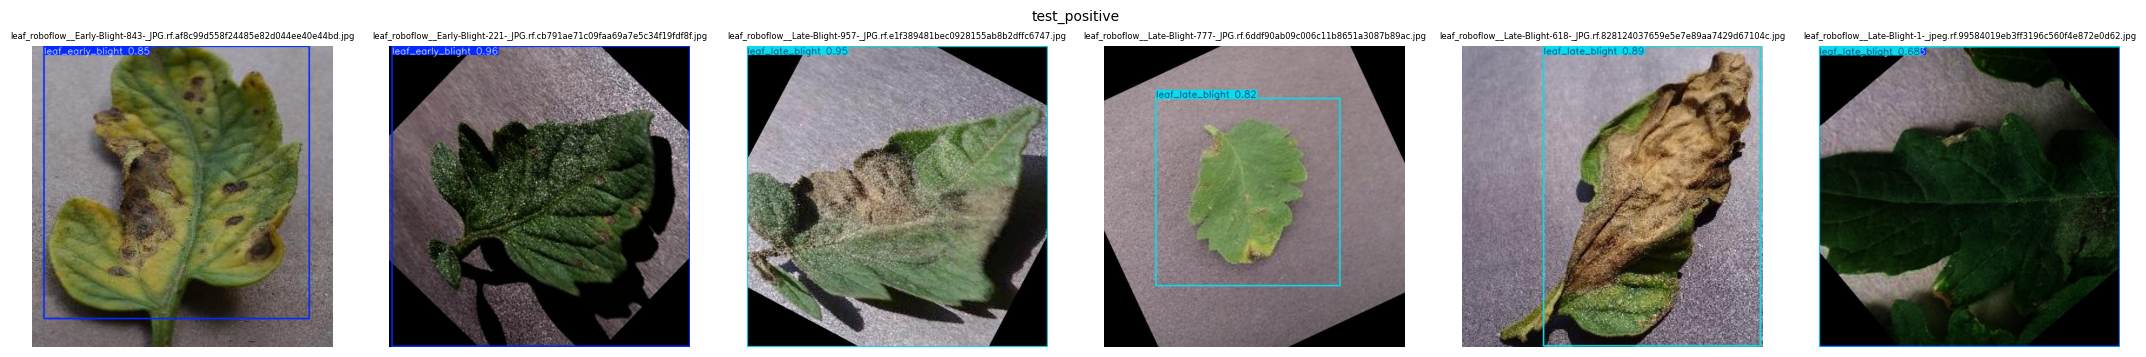

Đã lưu: /kaggle/working/reports/tomato_leaf_disease_v1_yolov8n_baseline/predictions_test_positive.png


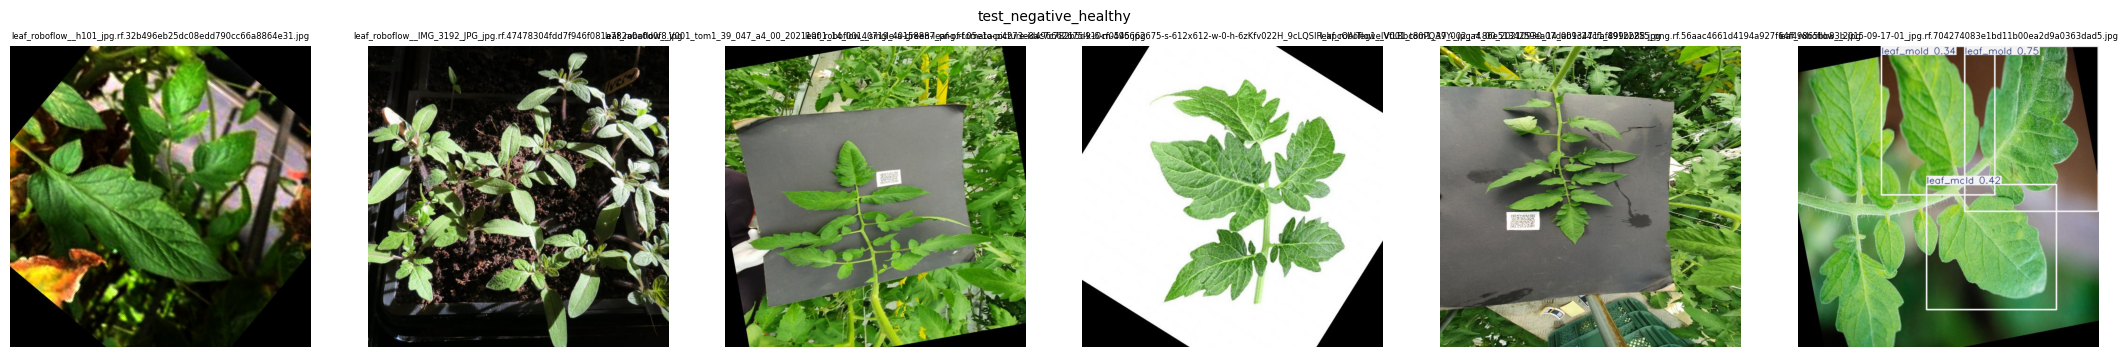

Đã lưu: /kaggle/working/reports/tomato_leaf_disease_v1_yolov8n_baseline/predictions_test_negative_healthy.png


In [8]:
import random

import matplotlib.pyplot as plt

random.seed(42)


def show_predictions(img_paths, n=6, title=""):
    img_paths = list(img_paths)
    if not img_paths:
        print(f"[{title}] Không có ảnh để hiển thị.")
        return
    sample = random.sample(img_paths, min(n, len(img_paths)))
    results = best_model.predict(source=[str(p) for p in sample], imgsz=640, conf=0.25, verbose=False)

    fig, axes = plt.subplots(1, len(sample), figsize=(3.6 * len(sample), 3.6))
    axes = [axes] if len(sample) == 1 else axes
    for ax, res, img_path in zip(axes, results, sample):
        annotated = res.plot()[:, :, ::-1]  # BGR -> RGB
        ax.imshow(annotated)
        ax.set_title(img_path.name, fontsize=6)
        ax.axis("off")
    fig.suptitle(title, fontsize=10)
    plt.tight_layout()
    save_path = REPORTS_DIR / f"predictions_{title.replace(' ', '_')}.png"
    plt.savefig(save_path, dpi=80, bbox_inches="tight")
    plt.show()
    plt.close(fig)
    print("Đã lưu:", save_path)


positive_images = [p for p in sorted(test_images_dir.glob("*")) if p not in set(negative_images)]
show_predictions(positive_images, title="test_positive")
show_predictions(negative_images, title="test_negative_healthy")

## Kết quả
- `models/tomato_leaf_disease_yolov8n_baseline.pt` — checkpoint tốt nhất theo val.
- `reports/tomato_leaf_disease_v1_yolov8n_baseline/` — `train_config.yaml`, `metrics_per_class_test.csv`, `metrics_summary_test.csv` (bao gồm tỷ lệ báo động giả trên lá khỏe), ảnh dự đoán mẫu.
- `runs/tomato_leaf_disease_v1_yolov8n_baseline/` — loss curve, `confusion_matrix.png`, `PR_curve.png`, `args.yaml`.

## Trước khi Save Version — checklist
- [ ] Bước 4: Precision/Recall/mAP@0.5 trên `test` — đối chiếu mục tiêu MVP tham khảo.
- [ ] Bước 5: tỷ lệ báo động giả trên ảnh lá khỏe — nếu cao, ảnh hưởng trực tiếp trải nghiệm người dùng (báo bệnh sai liên tục).
- [ ] Bước 7: ảnh dự đoán mẫu — box có khoanh đúng vùng bệnh không, ảnh negative có thực sự không bị báo bệnh không.
- [ ] Xem `runs/.../confusion_matrix.png` để biết model hay nhầm giữa 2 bệnh nào nhất.

## Bước tiếp theo
- Cả hai nhánh (`tomato_ripeness_v1` và `tomato_leaf_disease_v1`) đã có baseline — theo mục 1 của `HUONG_DAN_XAY_DUNG_DATASET_SMART_GREENHOUSE_AI.md`, chỉ nên thử gộp thành 1 model đa lớp (9 class: 4 bệnh lá + 3 độ chín + phần mở rộng) **sau khi cả hai baseline đã ổn định** — chưa vội gộp ngay.
- Nếu số liệu đạt mục tiêu: cân nhắc train phiên bản chính thức, ưu tiên cải thiện dữ liệu/nhãn (vd giải quyết 8.884 ảnh bị loại vì bệnh ngoài phạm vi MVP, hoặc quyết định gộp `leaf_zenodo` sau khi audit kỹ hơn) hơn là chỉ tăng epoch.
- Thu thập ảnh lá thật từ camera IMX179 trong nhà kính để làm tập test thực tế trước khi triển khai Raspberry Pi.